In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

project_root = Path.cwd()
if not (project_root / 'results' / 'experiment_results.csv').exists():
    project_root = project_root.parent

results_dir = project_root / 'results'
agg = pd.read_csv(results_dir / 'experiment_results.csv')
detail = pd.read_csv(results_dir / 'per_series_results.csv')
agg, detail.head()

(      model_class          model   scaling     mae_mean    rmse_mean  \
 0        baseline        AutoETS      none   451.567705   543.284588   
 1        baseline        AutoETS  quantile   494.489095   592.503821   
 2        baseline        AutoETS    robust   445.816992   536.071400   
 3        baseline        AutoETS  standard   444.574654   536.120802   
 4        baseline      AutoTheta      none   503.811771   592.803291   
 5        baseline      AutoTheta  quantile   490.162387   590.962488   
 6        baseline      AutoTheta    robust   507.103797   596.221870   
 7        baseline      AutoTheta  standard   505.176018   594.572839   
 8        baseline          Naive      none   602.155779   688.334392   
 9        baseline          Naive  quantile   602.155779   688.334392   
 10       baseline          Naive    robust   602.155779   688.334392   
 11       baseline          Naive  standard   602.155779   688.334392   
 12       baseline  SeasonalNaive      none   587.8

## Сводные таблицы сравнения

Для всех метрик ниже меньшие значения означают лучшее качество.

In [18]:
for metric in ['mae_mean', 'rmse_mean', 'smape_mean', 'mase_mean']:
    print(f'\n{metric}')
    display(agg.pivot(index='model', columns='scaling', values=metric).round(4))


mae_mean


scaling,none,quantile,robust,standard
model,,,,
AutoETS,451.5677,494.4891,445.8170,444.5747
AutoTheta,503.8118,490.1624,507.1038,505.1760
CatBoost,514.6166,561.7072,529.2983,502.2137
Naive,602.1558,602.1558,602.1558,602.1558
PatchTST,3925.3791,523.6682,506.5551,523.3021
SeasonalNaive,587.8754,587.8754,587.8754,587.8754



rmse_mean


scaling,none,quantile,robust,standard
model,,,,
AutoETS,543.2846,592.5038,536.0714,536.1208
AutoTheta,592.8033,590.9625,596.2219,594.5728
CatBoost,600.9781,665.5722,623.5040,599.6423
Naive,688.3344,688.3344,688.3344,688.3344
PatchTST,3970.7834,622.0476,597.0387,616.3473
SeasonalNaive,700.5468,700.5468,700.5468,700.5468



smape_mean


scaling,none,quantile,robust,standard
model,,,,
AutoETS,11.0930,12.1408,10.8377,10.7865
AutoTheta,13.8238,11.9304,13.9669,13.9375
CatBoost,12.7612,13.5370,13.1128,11.8882
Naive,13.3107,13.3107,13.3107,13.3107
PatchTST,199.5933,12.7952,12.4294,12.4353
SeasonalNaive,14.4729,14.4729,14.4729,14.4729



mase_mean


scaling,none,quantile,robust,standard
model,,,,
AutoETS,0.8449,0.9216,0.8518,0.8521
AutoTheta,0.9110,0.9189,0.9156,0.9156
CatBoost,1.1133,1.0668,0.9998,0.9404
Naive,1.1531,1.1531,1.1531,1.1531
PatchTST,19.5069,1.0657,1.0435,1.0158
SeasonalNaive,1.1234,1.1234,1.1234,1.1234


## Сравнение агрегированных метрик

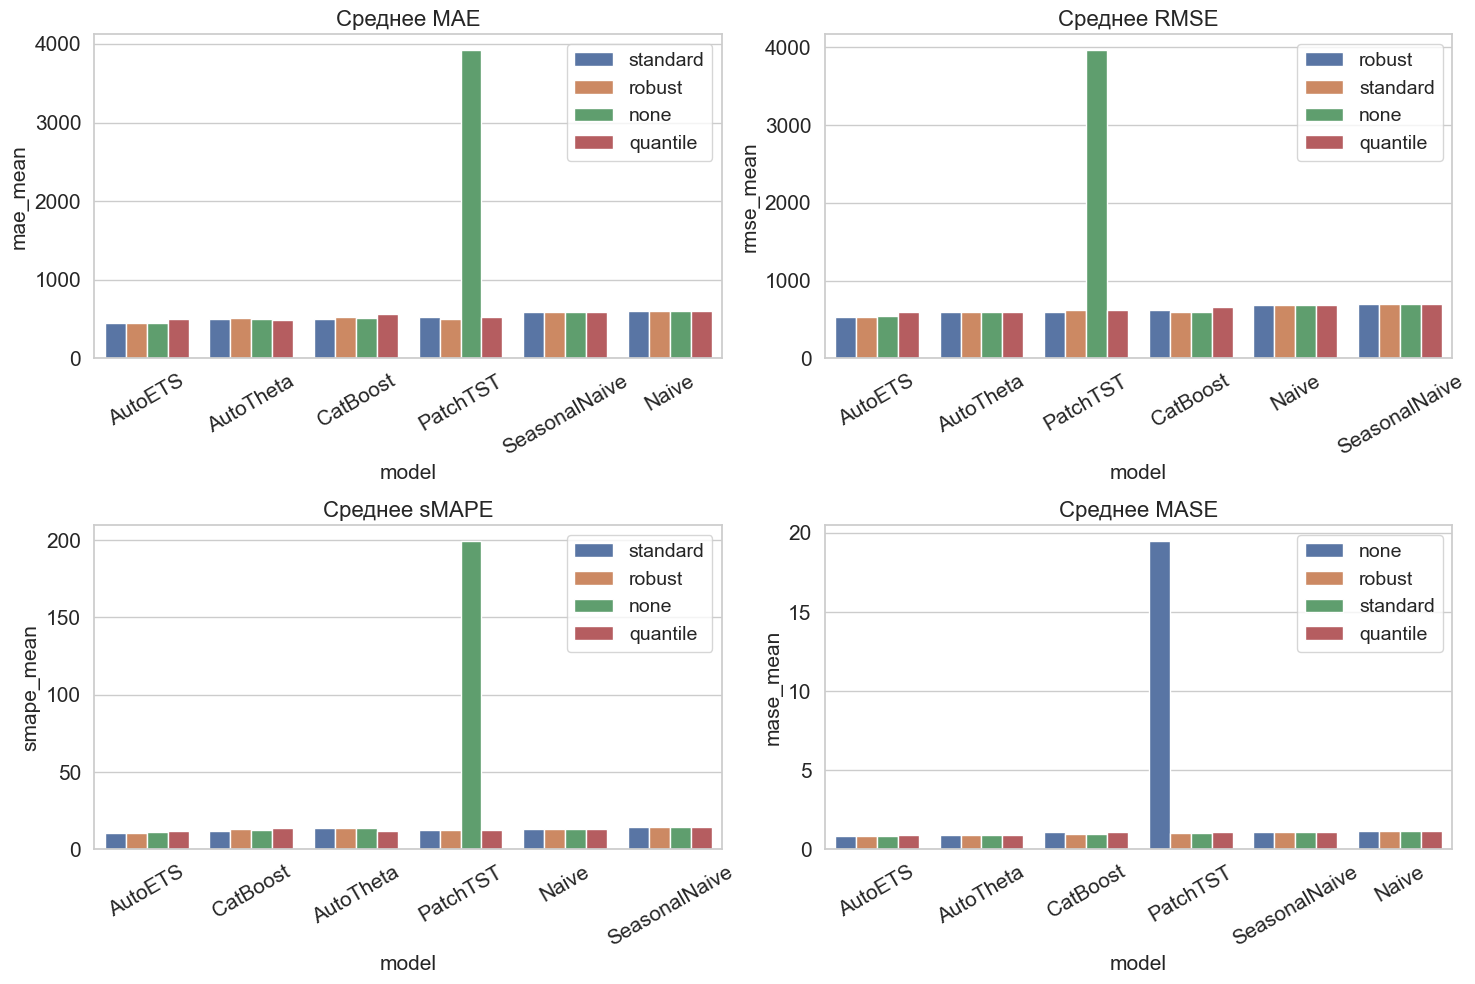

In [10]:
title_map = {
    'mae_mean': 'Среднее MAE',
    'rmse_mean': 'Среднее RMSE',
    'smape_mean': 'Среднее sMAPE',
    'mase_mean': 'Среднее MASE',
}
metrics = ['mae_mean', 'rmse_mean', 'smape_mean', 'mase_mean']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for ax, metric in zip(axes, metrics, strict=True):
    plot_df = agg.sort_values(metric)
    sns.barplot(data=plot_df, x='model', y=metric, hue='scaling', ax=ax)
    ax.set_xlabel("model", fontsize=15)
    ax.set_ylabel(metric, fontsize=15)
    ax.set_title(title_map[metric], fontsize=16)
    ax.tick_params(axis='x', rotation=30, labelsize=15)
    ax.tick_params(axis='y', labelsize=15)
    ax.legend(fontsize=14, title_fontsize=14)
plt.tight_layout()
plt.show()

## Распределения метрик по отдельным рядам

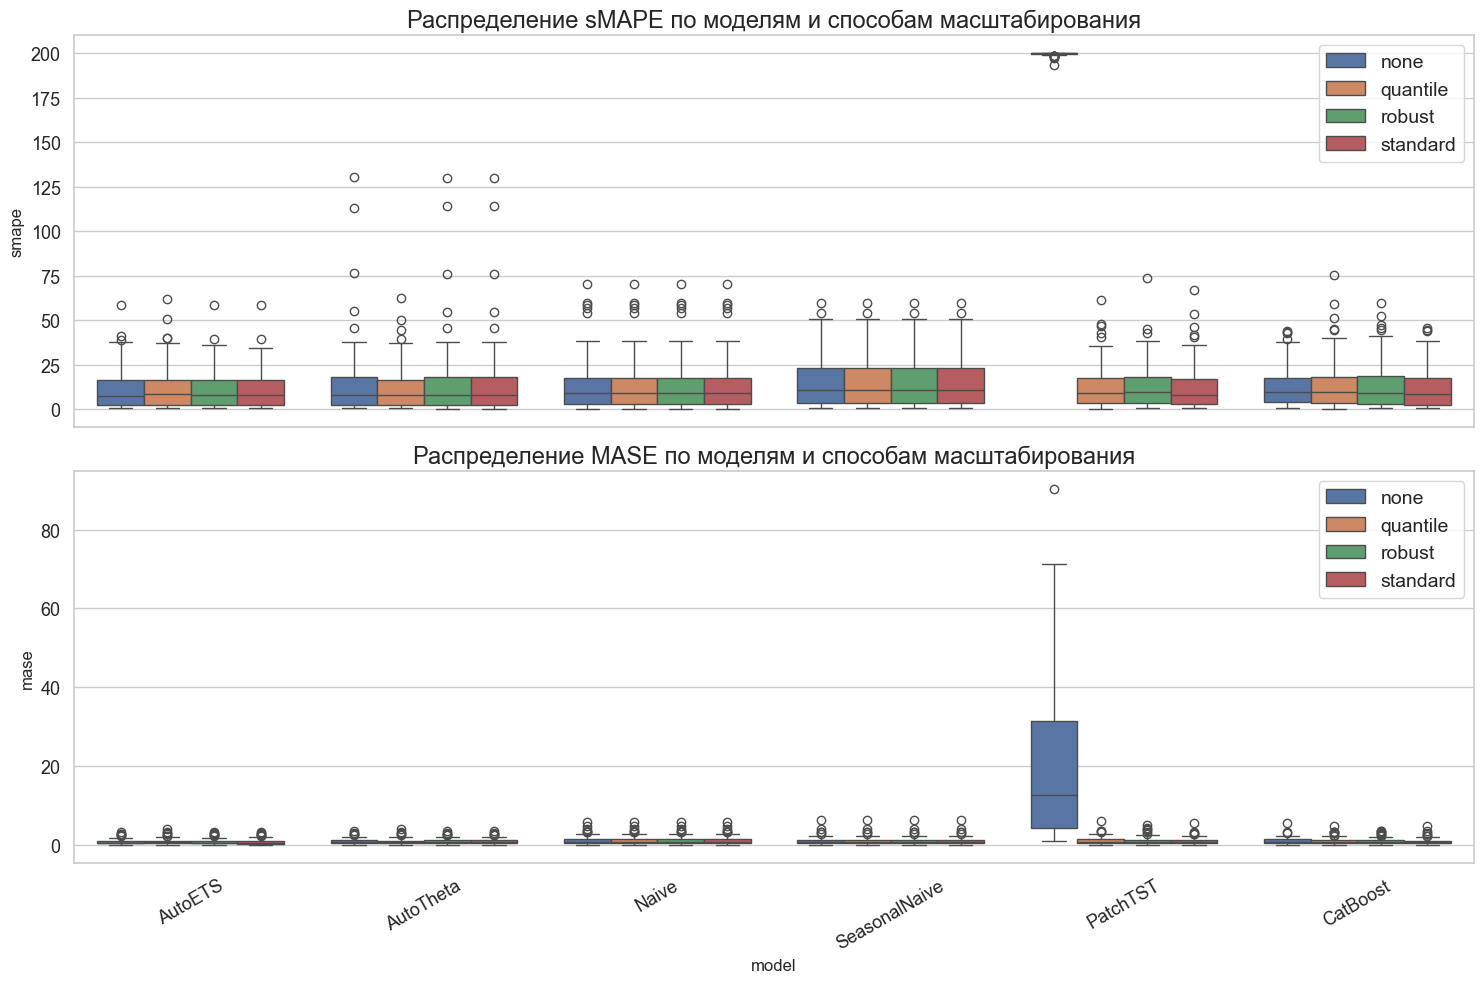

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
sns.boxplot(data=detail, x='model', y='smape', hue='scaling', ax=axes[0])
axes[0].set_title('Распределение sMAPE по моделям и способам масштабирования', fontsize=17)
axes[0].set_xlabel("model", fontsize=18)
axes[0].set_xlabel("smape", fontsize=18)
sns.boxplot(data=detail, x='model', y='mase', hue='scaling', ax=axes[1])
axes[1].set_title('Распределение MASE по моделям и способам масштабирования', fontsize=17)
axes[0].set_xlabel("mase", fontsize=18)
for ax in axes:
    ax.tick_params(axis='x', rotation=30, labelsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.legend(fontsize=14, title_fontsize=14)
plt.tight_layout()
plt.show()

## Сравнение классов моделей по отдельности

,model_class,model,scaling,mae_mean,rmse_mean,smape_mean,mase_mean,sample_size,horizon,seed
0,baseline,AutoETS,none,451.567705,543.284588,11.092991,0.844873,100,18,42
1,baseline,AutoETS,quantile,494.489095,592.503821,12.140795,0.921555,100,18,42
2,baseline,AutoETS,robust,445.816992,536.071400,10.837660,0.851843,100,18,42
3,baseline,AutoETS,standard,444.574654,536.120802,10.786506,0.852114,100,18,42
4,baseline,AutoTheta,none,503.811771,592.803291,13.823807,0.911013,100,18,42
5,baseline,AutoTheta,quantile,490.162387,590.962488,11.930447,0.918947,100,18,42
6,baseline,AutoTheta,robust,507.103797,596.221870,13.966888,0.915646,100,18,42
7,baseline,AutoTheta,standard,505.176018,594.572839,13.937542,0.915624,100,18,42
8,baseline,Naive,none,602.155779,688.334392,13.310673,1.153144,100,18,42
9,baseline,Naive,quantile,602.155779,688.334392,13.310673,1.153144,100,18,42


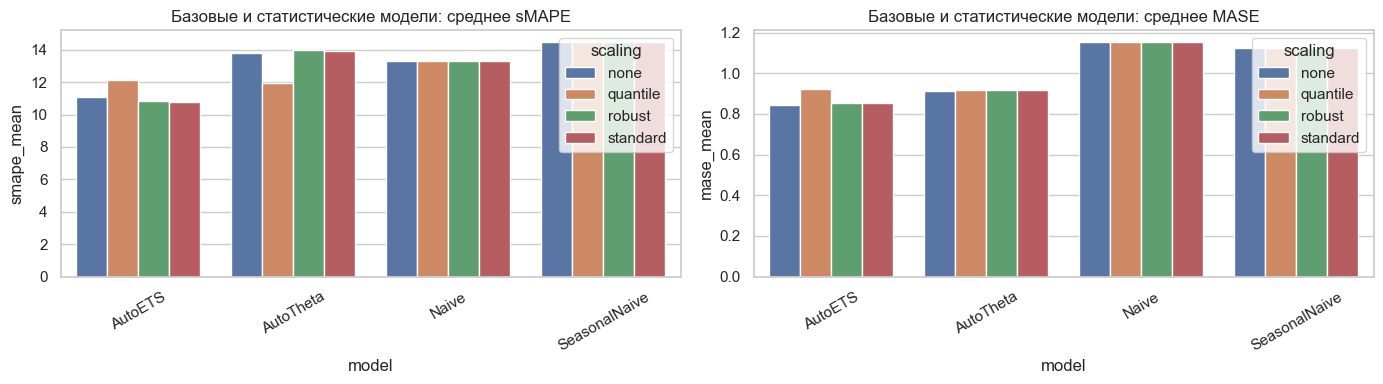

,model_class,model,scaling,mae_mean,rmse_mean,smape_mean,mase_mean,sample_size,horizon,seed
20,tree_global,CatBoost,none,514.616581,600.978094,12.761190,1.113340,100,18,42
21,tree_global,CatBoost,quantile,561.707232,665.572169,13.536988,1.066768,100,18,42
22,tree_global,CatBoost,robust,529.298325,623.503997,13.112837,0.999767,100,18,42
23,tree_global,CatBoost,standard,502.213669,599.642270,11.888190,0.940405,100,18,42


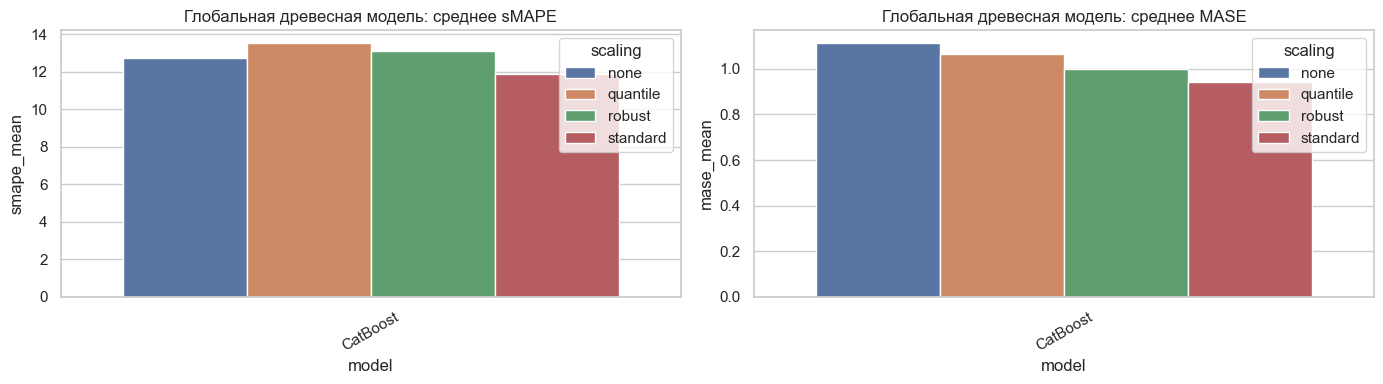

,model_class,model,scaling,mae_mean,rmse_mean,smape_mean,mase_mean,sample_size,horizon,seed
16,neural_global,PatchTST,none,3925.379097,3970.783430,199.593305,19.506881,100,18,42
17,neural_global,PatchTST,quantile,523.668210,622.047569,12.795213,1.065744,100,18,42
18,neural_global,PatchTST,robust,506.555087,597.038684,12.429450,1.043504,100,18,42
19,neural_global,PatchTST,standard,523.302131,616.347283,12.435292,1.015777,100,18,42


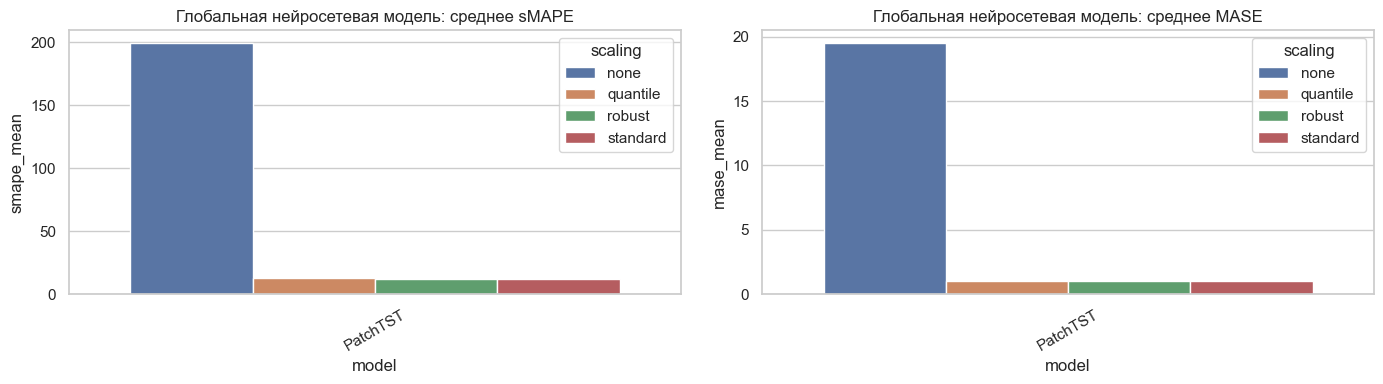

In [5]:
class_title_map = {
    'baseline': 'Базовые и статистические модели',
    'tree_global': 'Глобальная древесная модель',
    'neural_global': 'Глобальная нейросетевая модель',
}
for model_class in ['baseline', 'tree_global', 'neural_global']:
    subset = agg[agg['model_class'] == model_class].copy()
    display(subset.sort_values(['model', 'scaling']))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=subset, x='model', y='smape_mean', hue='scaling', ax=axes[0])
    axes[0].set_title(f"{class_title_map[model_class]}: среднее sMAPE")
    sns.barplot(data=subset, x='model', y='mase_mean', hue='scaling', ax=axes[1])
    axes[1].set_title(f"{class_title_map[model_class]}: среднее MASE")
    for ax in axes:
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()